##### Clusters de risco (prevenção de defasagem)
- Features: Defasagem, Fase vs Fase ideal, IDA, IEG, IPS, IAN, IPV. 

##### Dicionário Dados Datathon
- Algoritmos: KMeans / HDBSCAN 

##### Perguntas
- Quais grupos têm sinais de risco “silencioso” (ex.: notas ok, mas IPS/IEG ruins)?
- Existem clusters onde a defasagem é alta mesmo com INDE razoável (alerta de inconsistência/viés)?

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

df = pd.read_csv("base_dados_pede_2024_ajustado.csv")

k=5 | inertia=4170.6460

Tamanhos dos clusters:
cluster5
0    104
1    169
2     69
3    339
4    179
Name: count, dtype: int64

=== Cartão do Cluster (k=5) ===
            n   pv_rate  defasagem_media  gap_fase_medio  inde_medio  ida_media  ieg_media  ips_media  ian_media  ipv_medio
cluster5                                                                                                                   
0         104  0.201923        -1.538462        1.538462    7.092433   6.422115   7.902885   6.918269   4.735577   7.597096
1         169  0.000000        -1.437870        1.461538    5.502130   3.456213   5.673373   6.675148   5.103550   5.937692
3         339  0.144543        -1.247788        1.247788    7.287236   6.900295   8.610029   6.987021   4.985251   7.614897
2          69  0.101449         0.028986        1.971014    7.763145   7.297101   8.185507   7.207246  10.000000   7.543928
4         179  0.201117         0.072626       -0.072626    7.696134   6.397765   8.503352   6.

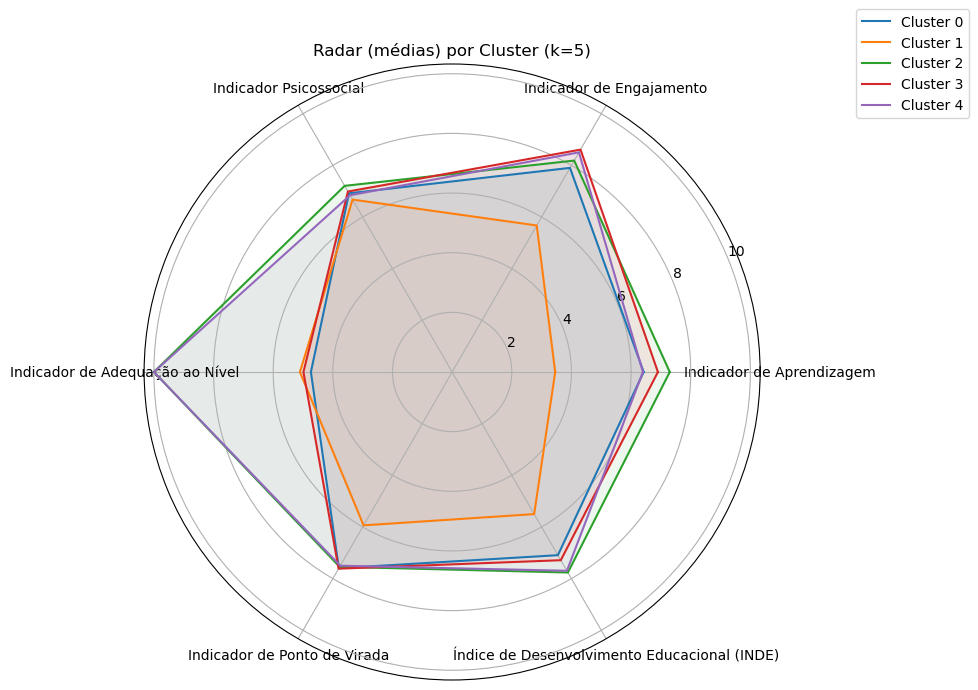


=== Simulação (Cluster 1) ===
INDE base: 5.502 -> INDE estimado: 6.210
Detalhes:
- Indicador de Aprendizagem: 3.46 -> 6.00 | Δ=2.54 | peso=0.20 | contrib=0.509
- Indicador de Engajamento: 5.67 -> 7.00 | Δ=1.33 | peso=0.15 | contrib=0.199

Arquivos gerados:
- results/cluster_card_risco_k5.csv
- results/base_com_clusters_k5.csv
- results/cluster_feature_zmeans_k5.csv
- results/cluster_feature_importance_absz_k5.csv
Salvo modelo: model/model.pkl


In [2]:
# helpers

def parse_fase_ideal(x):
    """
    (Aluno) Tento extrair um número da string 'Fase ideal'.
    - Se a célula estiver vazia retorna np.nan.
    - Uso regex para pegar o primeiro número encontrado.
    Exemplo: '6ª série' -> 6.0
    """
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    m = re.search(r"\d+", s)
    return float(m.group()) if m else np.nan

def normalize_bool_sim_nao(series):
    """
    (Aluno) Normaliza respostas tipo 'sim'/'não' para booleanos.
    - Converte tudo para string, tira espaços e deixa em minúsculas.
    - Considera várias formas de 'sim' como verdadeiras.
    Retorna uma Series booleana.
    """
    s = series.astype(str).str.strip().str.lower()
    return s.isin(["sim", "s", "true", "1", "yes", "y"])

def standardize_numpy(X):
    """
    (Aluno) Padroniza um array numpy por coluna.
    - Calcula média (mu) e desvio padrão (sigma) por coluna.
    - Se sigma == 0 substitui por 1.0 para evitar divisão por zero.
    Retorna: (X_padronizado, mu, sigma)
    """
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma == 0] = 1.0
    return (X - mu) / sigma, mu, sigma

def kmeans_numpy(X, k, n_init=30, max_iter=600, seed=42):
    """
    (Aluno) Implementação simplificada do KMeans usando apenas numpy.

    Parâmetros:
    - X: array shape (n_samples, n_features)
    - k: número de clusters
    - n_init: quantas inicializações aleatórias tentar
    - max_iter: iterações por inicialização
    - seed: semente para reprodutibilidade

    Retorna: (labels, centroids, inertia)
    - labels: array com rótulo de cluster por amostra
    - centroids: array (k, n_features) com centroides finais
    - inertia: soma dos quadrados dentro dos clusters (menor = melhor)
    """
    rng = np.random.default_rng(seed)
    best_inertia = np.inf
    best_labels = None
    best_centroids = None
    n = X.shape[0]

    for _ in range(n_init):
        idx = rng.choice(n, size=k, replace=False)
        centroids = X[idx].copy()

        for _ in range(max_iter):
            d2 = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
            labels = d2.argmin(axis=1)

            new_centroids = centroids.copy()
            for j in range(k):
                pts = X[labels == j]
                if len(pts) == 0:
                    new_centroids[j] = X[rng.integers(0, n)]
                else:
                    new_centroids[j] = pts.mean(axis=0)

            if np.allclose(new_centroids, centroids, atol=1e-6):
                centroids = new_centroids
                break
            centroids = new_centroids

        inertia = ((X - centroids[labels]) ** 2).sum()
        if inertia < best_inertia:
            best_inertia = inertia
            best_labels = labels.copy()
            best_centroids = centroids.copy()

    return best_labels, best_centroids, best_inertia

def plot_radar(cluster_means_raw, features, title="Radar dos Clusters"):
    """
    (Aluno) Cria um gráfico radar simples para comparar médias por cluster.
    - cluster_means_raw: DataFrame index=cluster, cols=features
    - features: lista de nomes de colunas a plotar
    - title: título do gráfico (opcional)
    """
    labels = cluster_means_raw.index.astype(str).tolist()
    num_vars = len(features)

    angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(8,8))
    ax = plt.subplot(111, polar=True)

    for c in cluster_means_raw.index:
        values = cluster_means_raw.loc[c, features].tolist()
        values += values[:1]
        ax.plot(angles, values, label=f"Cluster {c}")
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features)
    plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1.10))
    plt.title(title)
    plt.show()

# preparo de features

df["Fase_ideal_num"] = df["Fase ideal"].apply(parse_fase_ideal)
df["gap_fase"] = df["Fase_ideal_num"] - df["Fase"]
df["pv_bool"] = normalize_bool_sim_nao(df["Atingiu Ponto de Virada"])

risk_cols = [
    "Nível de Defasagem",
    "Fase",
    "Fase_ideal_num",
    "gap_fase",
    "Indicador de Aprendizagem",
    "Indicador de Engajamento",
    "Indicador Psicossocial",
    "Indicador de Adequação ao Nível",
    "Indicador de Ponto de Virada",
    "Índice de Desenvolvimento Educacional (INDE)",
]

missing = [c for c in risk_cols if c not in df.columns]
if missing:
    raise ValueError(f"Faltam colunas no df: {missing}")

X_df = df[risk_cols].copy()
X_df = X_df.apply(pd.to_numeric, errors="coerce")
X_df = X_df.fillna(X_df.mean(numeric_only=True))

X = X_df.to_numpy(dtype=float)
X_scaled, mu, sigma = standardize_numpy(X)

# treinamento KMeans (k=5)

k = 5
labels, centroids, inertia = kmeans_numpy(X_scaled, k=k, n_init=40, max_iter=700, seed=42)
df["cluster5"] = labels

print(f"k=5 | inertia={inertia:.4f}")
print("\nTamanhos dos clusters:")
print(df["cluster5"].value_counts().sort_index())

cluster_card5 = (
    df.groupby("cluster5")
      .agg(
          n=("RA", "count"),
          pv_rate=("pv_bool", "mean"),
          defasagem_media=("Nível de Defasagem", "mean"),
          gap_fase_medio=("gap_fase", "mean"),
          inde_medio=("Índice de Desenvolvimento Educacional (INDE)", "mean"),
          ida_media=("Indicador de Aprendizagem", "mean"),
          ieg_media=("Indicador de Engajamento", "mean"),
          ips_media=("Indicador Psicossocial", "mean"),
          ian_media=("Indicador de Adequação ao Nível", "mean"),
          ipv_medio=("Indicador de Ponto de Virada", "mean"),
      )
      .sort_values(["defasagem_media", "pv_rate"], ascending=[True, True]) # mais negativo é mais defasado (pior)
)

print("\n=== Cartão do Cluster (k=5) ===")
print(cluster_card5.to_string())

# Feature importance por cluster
# z-score médio por cluster (quanto mais distante de 0, mais característico)

X_scaled_df = pd.DataFrame(X_scaled, columns=risk_cols)
X_scaled_df["cluster5"] = df["cluster5"].values

z_means = X_scaled_df.groupby("cluster5")[risk_cols].mean()

# "importância" = |z| (distância do padrão geral)
z_importance = z_means.abs()

print("\n=== Top features (|z|) por cluster ===")
for c in z_importance.index:
    top = z_importance.loc[c].sort_values(ascending=False).head(5)
    print(f"\nCluster {c} - Top 5 features:")
    for feat, val in top.items():
        direction = "↑" if z_means.loc[c, feat] > 0 else "↓"
        print(f"  {feat}: {direction} (|z|={val:.2f}, z={z_means.loc[c, feat]:.2f})")

z_means.to_csv("results/cluster_feature_zmeans_k5.csv", index=True)
z_importance.to_csv("results/cluster_feature_importance_absz_k5.csv", index=True)

radar_features = [
    "Indicador de Aprendizagem",
    "Indicador de Engajamento",
    "Indicador Psicossocial",
    "Indicador de Adequação ao Nível",
    "Indicador de Ponto de Virada",
    "Índice de Desenvolvimento Educacional (INDE)",
]

cluster_means_raw = df.groupby("cluster5")[radar_features].mean()
plot_radar(cluster_means_raw, radar_features, title="Radar (médias) por Cluster (k=5)")

#  simulação de impacto no Cluster 1, como INDE é composto por indicadores (aprox), ajustar IDA e IEG e estima impacto aproximado em INDE.

def simulate_cluster_impact(cluster_id, new_values, weights):
    """
    (Aluno) Simula impacto aproximado no INDE médio de um cluster se alterarmos indicadores.

    Parâmetros:
    - cluster_id: id do cluster no `cluster_card5`
    - new_values: dict com valores alvo por indicador, ex: {"Indicador de Aprendizagem": 6.0}
    - weights: pesos que traduzem mudança no indicador para mudança no INDE (aproximação)

    Retorna: (inde_base, inde_new, details)
    - inde_base: valor médio atual do INDE no cluster
    - inde_new: INDE estimado após aplicar mudanças ponderadas
    - details: lista de tuplas (feat, current, target, delta, w, contrib) com contribuições
    """
    base = cluster_card5.loc[cluster_id].copy()
    inde_base = base["inde_medio"]

    delta_inde = 0.0
    details = []

    for feat, target in new_values.items():
        current = base.get({
            "Indicador de Aprendizagem": "ida_media",
            "Indicador de Engajamento": "ieg_media",
            "Indicador Psicossocial": "ips_media",
            "Indicador de Adequação ao Nível": "ian_media",
            "Indicador de Ponto de Virada": "ipv_medio",
        }.get(feat, feat), None)

        if current is None:
            continue

        delta = target - current
        w = weights.get(feat, 0.0)
        delta_inde += delta * w
        details.append((feat, current, target, delta, w, delta*w))

    inde_new = inde_base + delta_inde
    return inde_base, inde_new, details

# cenário: melhorar Cluster 1 (o que no seu resultado é o cluster com PV 0)
# Se no seu caso o "cluster crítico" não for 1, troque aqui.
cluster_critico = 1

# pesos conservadores (ajuste livre)
weights = {
    "Indicador de Aprendizagem": 0.20,
    "Indicador de Engajamento": 0.15,
    "Indicador Psicossocial": 0.10,
    "Indicador de Adequação ao Nível": 0.15,
    "Indicador de Ponto de Virada": 0.15,
}

# cenário 1: elevar IDA para 6 e IEG para 7
scenario = {
    "Indicador de Aprendizagem": 6.0,
    "Indicador de Engajamento": 7.0,
}

inde_base, inde_new, details = simulate_cluster_impact(cluster_critico, scenario, weights)

print(f"\n=== Simulação (Cluster {cluster_critico}) ===")
print(f"INDE base: {inde_base:.3f} -> INDE estimado: {inde_new:.3f}")
print("Detalhes:")
for feat, cur, tgt, delta, w, contrib in details:
    print(f"- {feat}: {cur:.2f} -> {tgt:.2f} | Δ={delta:.2f} | peso={w:.2f} | contrib={contrib:.3f}")

# salvar saídas

cluster_card5.to_csv("results/cluster_card_risco_k5.csv", index=True)
df.to_csv("results/base_com_clusters_k5.csv", index=False)

print("\nArquivos gerados:")
print("- results/cluster_card_risco_k5.csv")
print("- results/base_com_clusters_k5.csv")
print("- results/cluster_feature_zmeans_k5.csv")
print("- results/cluster_feature_importance_absz_k5.csv")

# salvar modelo KMeans (centroids + scaler) para uso futuro
import pickle
os.makedirs("results", exist_ok=True)
model = {
    "centroids": centroids,
    "mu": mu.tolist(),
    "sigma": sigma.tolist(),
    "risk_cols": risk_cols,
    "k": k,
    "inertia": float(inertia),
}
model_path = "model/model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)
print(f"Salvo modelo: {model_path}")

def predict_kmeans_model(df_new, model):
    """
    (Aluno) Usa centroids + mu/sigma salvos para predizer clusters em novos dados.

    Parâmetros:
    - df_new: DataFrame com colunas correspondentes a model['risk_cols']
    - model: dict salvo com centroids, mu, sigma, risk_cols

    Retorna: array de rótulos de cluster (ints)
    """
    X_df_new = df_new[model["risk_cols"]].copy()
    X_df_new = X_df_new.apply(pd.to_numeric, errors="coerce")
    mu_arr = np.array(model["mu"])
    sigma_arr = np.array(model["sigma"])
    X_df_new = X_df_new.fillna(pd.Series(mu_arr, index=model["risk_cols"]))
    X = X_df_new.to_numpy(dtype=float)
    X_scaled_new = (X - mu_arr) / sigma_arr
    centroids_arr = np.array(model["centroids"])
    d2 = ((X_scaled_new[:, None, :] - centroids_arr[None, :, :]) ** 2).sum(axis=2)
    labels_new = d2.argmin(axis=1)
    return labels_new

# Exemplo de uso (comentado):
# new_df = pd.read_csv('novos_alunos.csv')
# labels_pred = predict_kmeans_model(new_df, model)

In [ ]:
# Criação um DataFrame de novos alunos e predizer clusters
# Usa as colunas presentes em model['risk_cols'] e o dicionário 'model' já criado.
# Usando 3 primeiras linhas do df como exemplo
new_df = df[model['risk_cols']].head(3).copy()
new_df = new_df.apply(pd.to_numeric, errors='coerce')
# preenche NAs com as médias salvas no model
new_df = new_df.fillna(pd.Series(model['mu'], index=model['risk_cols']))
labels_pred = predict_kmeans_model(new_df, model)
print('labels_pred =', labels_pred)
new_df['cluster_pred'] = labels_pred
new_df.head()

labels_pred = [0 4 4]


,Nível de Defasagem,Fase,Fase_ideal_num,gap_fase,Indicador de Aprendizagem,Indicador de Engajamento,Indicador Psicossocial,Indicador de Adequação ao Nível,Indicador de Ponto de Virada,Índice de Desenvolvimento Educacional (INDE),cluster_pred
0,-1,7,8.0,1.0,4.0,4.1,5.6,5.0,7.278,5.783,0
1,0,7,7.0,0.0,6.8,5.2,6.3,10.0,6.778,7.055,4
2,0,7,7.0,0.0,5.6,7.9,5.6,10.0,7.556,6.591,4
